Base Model 2 : 이상치 제거 없이 클러스터링

In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('combined_features.csv')

In [6]:
cluster_feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

X_cluster = df[cluster_feature_cols].copy()

X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan)
X_cluster = X_cluster.dropna()

# X_cluster 인덱스에 맞추기
df = df.loc[X_cluster.index].copy()

print(X_cluster.shape)

(49731, 8)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

C:\asdf\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\asdf\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\asdf\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\asdf\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\asdf\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(a

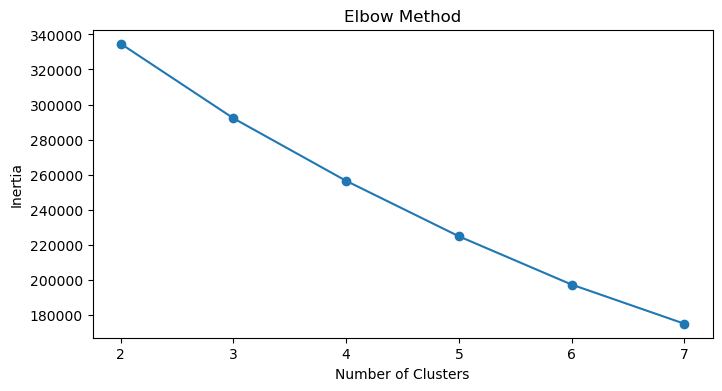

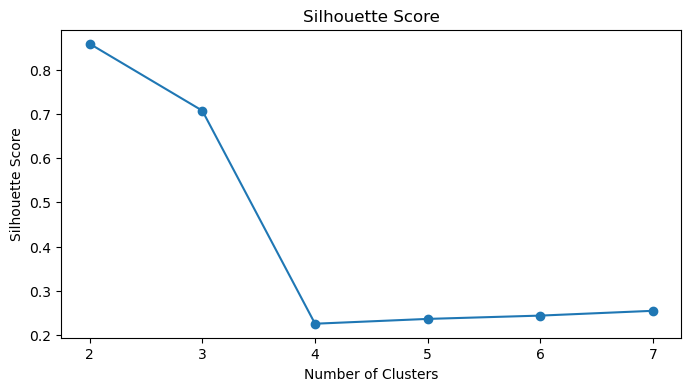

,k,inertia,silhouette
0,2,334697.992527,0.858432
1,3,292141.900430,0.707182
2,4,256432.014366,0.225890
3,5,224795.250721,0.236764
4,6,197248.768605,0.244252
5,7,174908.673432,0.255103


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), silhouette_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

pd.DataFrame({
    "k": list(K_range),
    "inertia": inertias,
    "silhouette": silhouette_scores
})

In [10]:
#k=3으로 k-means 진행
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_cluster_scaled)

df["cluster"].value_counts().sort_index()

cluster
0    48614
1      185
2      932
Name: count, dtype: int64

In [12]:
#베이스 모델의 성능을 시각화를 통해 확인하기 위해 tsne으로 차원 감소 및 산점도로 시각화
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(df[cluster_feature_cols])

In [17]:
df_tsne = pd.DataFrame(tsne_results, columns=['tsne_1', 'tsne_2'])
df_tsne['cluster'] = df['cluster']

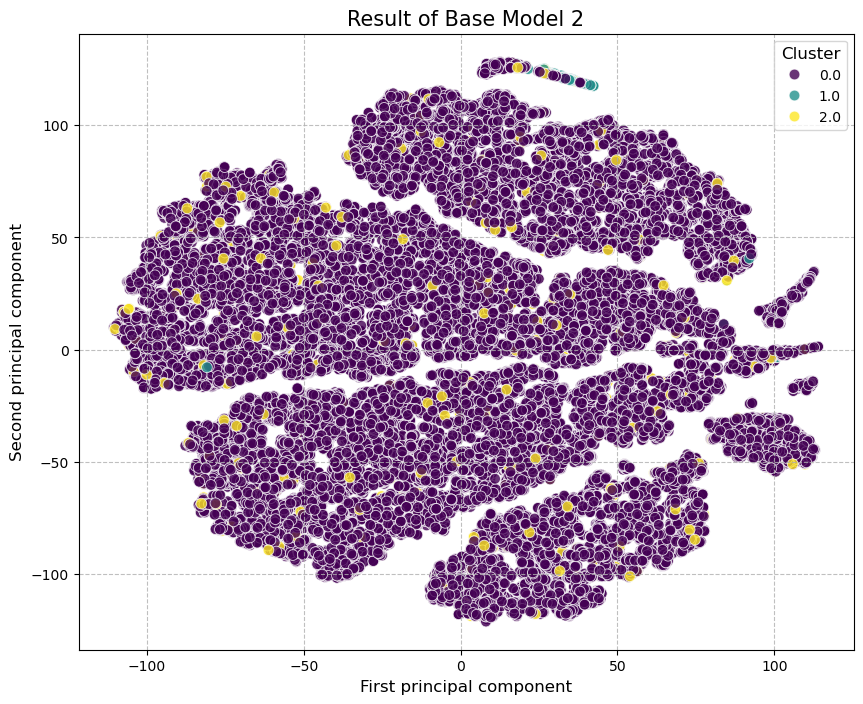

In [21]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.scatterplot(data=df_tsne, x='tsne_1', y='tsne_2', hue='cluster', 
                palette='viridis', s=60, alpha=0.8, edgecolor='w', legend='full')

plt.title('Result of Base Model 2', fontsize=15)
plt.xlabel('First principal component', fontsize=12)
plt.ylabel('Second principal component', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.8)
plt.legend(title='Cluster', title_fontsize=12, fontsize=10)
plt.savefig('base_model2_result.png', dpi=300, bbox_inches="tight")
plt.show()